In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import boxcox

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.model_selection import RepeatedKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

from itertools import product

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


# DOWNLOAD NISAR-AGB-CANOPY DATA

In [3]:
NISAR_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/NISAR/Nisar_AGB_CANOPY.csv"

nisar_df = pd.read_csv(NISAR_DATA_CSV)
print(nisar_df.shape)
nisar_df.columns

(3176, 15)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'date',
       'nisar_value_hvhv', 'nisar_value_hhhh', 'simard_height_m',
       'tandemx_height_m'],
      dtype='object')

In [4]:
assert len(nisar_df["simard_height_m"].head())
assert len(nisar_df["tandemx_height_m"].head())

In [5]:
nisar_df['dataset'].unique()

array(['ElSalvador', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Maruipe', 'Brazil-BocaGrande', 'Brazil-Barreto',
       'Brazil-Salinas', 'Brazil-FuroGrande', 'Brazil-Caetano'],
      dtype=object)

### Select features

In [6]:
non_feature_cols = [
    #'plant_AGB_kg',       # Target variable
    'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',           # coordinate
    'longitude',          # coordinate
    'diameter',            # Allometric
    'height',              # Allometric
    'cloud_threshold_used'
]

nisar_bands = ['nisar_value_hhhh', 'nisar_value_hvhv']
useful_categorical = ['plot_id', 'species']
struct_features = ['height']

target = 'plant_AGB_kg'
feature_cols = [c for c in nisar_df.columns if c not in non_feature_cols]

X = nisar_df[feature_cols]
y = nisar_df[target]

# Select TANDEMX
X = X.rename({'tandemx_height_m': 'height'}, axis=1)
X = X.drop(columns=['simard_height_m'])

# Select SIMARD
#X = X.rename({'simard_height_m': 'height'}, axis=1)
#X = X.drop(columns=['tandemx_height_m'])

print(f"Features: {feature_cols}")

Features: ['plot_id', 'species', 'plant_AGB_kg', 'date', 'nisar_value_hvhv', 'nisar_value_hhhh', 'simard_height_m', 'tandemx_height_m']


In [7]:
# Retain the groups/plot_id for splitting the data based on groups.
plot_groups = X['plot_id'].copy()
site_groups = plot_groups.map(lambda x: x.rsplit('_', maxsplit=1)[0])

## DATA PREPROCESSING

In [8]:
null_rows   = X[X.isnull().any(axis=1)]
total_nulls = X.isnull().sum().sum()

print(f"Total NULL count           : {total_nulls}")
print(f"Rows with at least one NULL: {len(null_rows)}")
print(f"Total rows                 : {len(X)}")
print(f"Percentage                 : {len(null_rows)/len(X)*100:.1f}%")

# NULL count per column for only the affected rows
null_col_counts = null_rows.isnull().sum().sort_values(ascending=False)
print("\nNULL count per column in affected rows:")
print(null_col_counts[null_col_counts > 0])

Total NULL count           : 0
Rows with at least one NULL: 0
Total rows                 : 3176
Percentage                 : 0.0%

NULL count per column in affected rows:
Series([], dtype: int64)


In [9]:
assert not total_nulls
#X = handle_null_data(X)
#X = X.dropna()
#print(X.shape)
#X.columns

### Find correlations

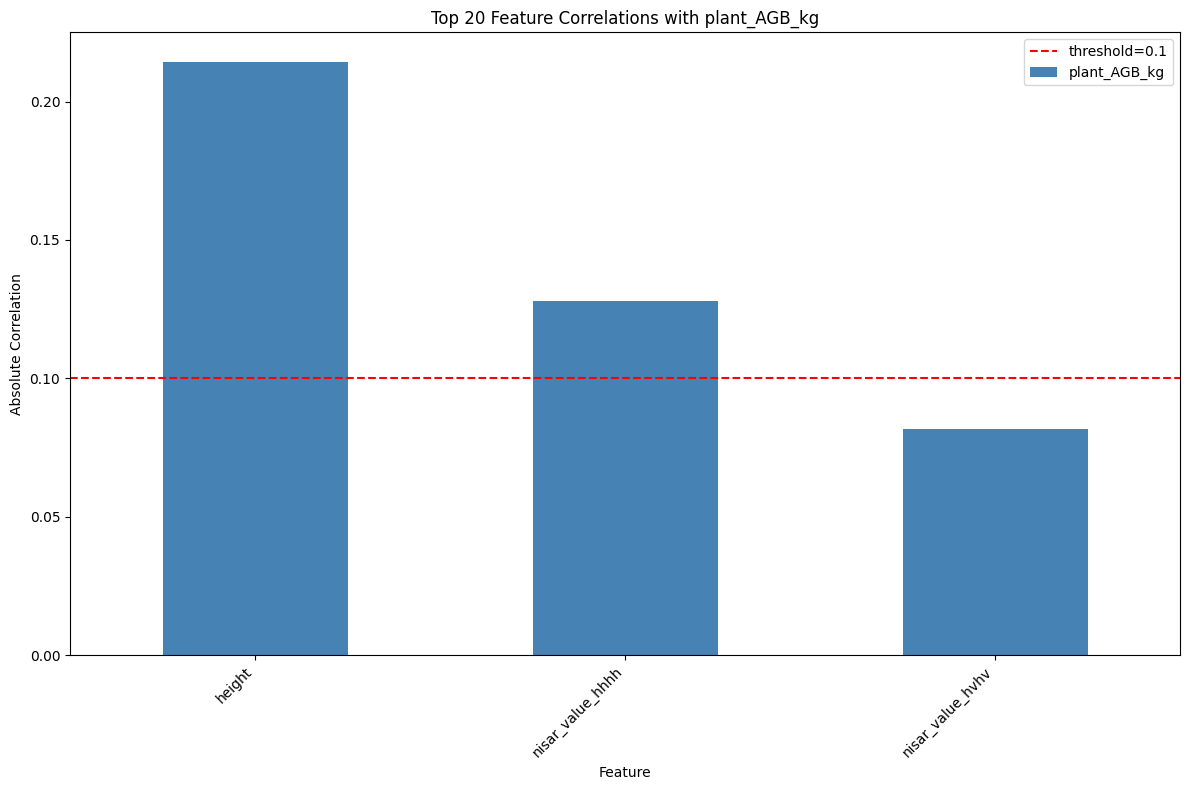

height              0.214328
nisar_value_hhhh    0.127950
nisar_value_hvhv    0.081804
Name: plant_AGB_kg, dtype: float64


In [10]:
numerical_cols = get_numerical_cols(X)
target_corr = plot_correlation_matrix(X[numerical_cols],
                                      X['plant_AGB_kg'],
                                      top_n=20)
print(target_corr)

**COMMENTS:**  
Columns with a Pearson correlation coefficient (r) between -0.1 and 0.1 with the target variable are generally considered to have a negligible or very weak relationship.

### Remove Low Variance Features (cols)

#### Is variance threshold valid for sentinel-2 data?

- Sentinel-2 surface reflectance values are typically in the range 0.0 to 0.3.  
 - Their absolute variance is naturally small — not because they carry no information but because their scale is small.  
 - A feature with values ranging from 0.05 to 0.25 has variance of ~0.003, which falls below the 0.01 threshold, but the variation within that range is meaningful for AGB prediction.  
 - VarianceThreshold is designed for features with near-identical values across all rows — like a binary column that is always 0.  
 - It is not appropriate for bounded continuous features like reflectance values.

### Remove Features With Weak Correlation to Target

#### Why Pearson correlation is unreliable here?

Pearson correlation measures linear relationship between a feature and the target. 

The above correlation removal process is based on the correlations computed against the original y. But we are going log-transform the target for modeling. 

A feature can have a strong non-linear relationship with AGB that shows up clearly after log transformation but appears weak in linear correlation against raw AGB.  

The experiments (Belige-data-analysis.ipynb) already proved these features are useful.  

In [11]:
X = remove_uncorrelated_categorical_cols(X, y)
assert X is not None

X.columns


--- plot_id ---
Variable  : plot_id
F-stat    : 4.8546
p-value   : 0.0000
Relevant? : True

--- species ---
Variable  : species
F-stat    : 20.7686
p-value   : 0.0000
Relevant? : True

--- date ---
date : skipped — fewer than 2 valid groups after filtering

   feature  relevant?
0  plot_id       True
1  species       True
2     date      False


Strong correlations kept   : 6
Weak correlations removed: 1


Index(['plot_id', 'species', 'plant_AGB_kg', 'nisar_value_hvhv',
       'nisar_value_hhhh', 'height'],
      dtype='object')

### Convert categorical variables to one-hot encoding

# What would actually constitute a good result?
For a model to be trustworthy you would want to see:
 - Grouped CV mean above 0.40
 - Grouped CV std below 0.15
 - No individual grouped CV fold below -0.10
 - Regular CV and grouped CV in the same ballpark — large divergence between them signals leakage
 - Test R² close to grouped CV mean, not far above it

In [12]:
%run Model_functions.ipynb

**Determine near_zero_threshold, and high_agb_threshold**  
**near_zero_threshold = 1.0 kg**
 - Any site where the heaviest plant weighs less than 1 kg has near-zero AGB variance.
 - From your data Frenchman Caye (max 0.26 kg) and Shipstern (max 0.94 kg) fall below this.
 - R² is meaningless for these sites as a holdout set.
 - In other words, R² is mathematically unstable when the holdout set has near-zero variance.

**R² is defined as:** 1 - (sum of squared residuals / total sum of squares)
**Total sum of squares is (denominator):** sum of (y - mean(y))²
**Problem:**  
 - When every plant in the holdout site weighs between 0.001 and 0.26 kg, the mean is ~0.03 kg and every value is very close to that mean.
 - This makes the total sum of squares as near-zero.
 - Any prediction error, however small will produce a large negative R² because of the near-zero denominator.

**high_agb_threshold = 100.0 kg**
 - Any site with trees above 100 kg is potentially ecologically distinct from the rest.
 - From your data Channel Caye (max 427 kg) and New River (max 261 kg) fall above this.
 - These are the sites where generalization failure is a genuine concern.

In [13]:
near_zero_sites, high_agb_sites, near_zero_plots, high_agb_plots = \
    get_low_and_high_agb_plots(y, plot_groups)

High-AGB threshold  : 3110.16 kg
Near-zero threshold : 0.002791

Near-zero variance plots:

High-AGB plots:
  BOC_Boca Grande           : max AGB = 5572.3 kg
  CAE_Caetano               : max AGB = 5248.5 kg
  El_Plan_de_la_Ceiba_8_1   : max AGB = 5199.1 kg
  El_Plan_de_la_Ceiba_8_3   : max AGB = 3403.8 kg
  El_Plan_de_la_Ceiba_8_6   : max AGB = 5765.0 kg
  MAN_Mangue Sul            : max AGB = 7172.7 kg
  Montecristo_21_2          : max AGB = 4711.5 kg
  Montecristo_21_3          : max AGB = 5765.0 kg
  Montecristo_22_2          : max AGB = 9617.2 kg
  Montecristo_22_3          : max AGB = 11337.3 kg
  Montecristo_22_4          : max AGB = 3179.8 kg

within-site high-AGB plots
Bordo_del_Chile_23   : within-site high-AGB plots = ['Bordo_del_Chile_23_2']
Santo_Domingo_5      : within-site high-AGB plots = ['Santo_Domingo_5_2']
El_Espino_6          : within-site high-AGB plots = ['El_Espino_6_1']
La_Herradura_7       : within-site high-AGB plots = ['La_Herradura_7_2']
San_Antonio_Los_Bla

In [14]:
features_list = [struct_features, 
                 struct_features + useful_categorical,
                 struct_features + nisar_bands,
                 nisar_bands,
                 nisar_bands + useful_categorical,
                 nisar_bands + struct_features + useful_categorical]

model_list = ["regular", "ridge", "lasso", "elasticnet"]

test_cv = 5
#test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

In [15]:
# Group by dataset instead of plot/site
dataset_groups = nisar_df['dataset']

# LINEAR REGRESSION

In [16]:
%run Model_functions.ipynb
lin_experiments = {}

In [ ]:
%run Model_functions.ipynb

from sklearn.model_selection import LeaveOneGroupOut

def split_data_by_groups_logo(X_var, y_var, groups):
    logo   = LeaveOneGroupOut()
    splits = []
    for train_idx, test_idx in logo.split(X_var, y_var, groups=groups):
        X_train = X_var.iloc[train_idx]
        X_test  = X_var.iloc[test_idx]
        y_train = y_var.iloc[train_idx]
        y_test  = y_var.iloc[test_idx]
        splits.append((X_train, X_test, y_train, y_test))
    return splits




In [ ]:
def run_lin_experiment(model_type, X_df, y, features,
                       is_groups, groups, test_cv, idx,label_in):
    label = f"EXPERIMENT-{idx} {label_in}, Model: {model_type}, Features: {features}"
    
    X = X_df[features]
    categorical_cols = get_categorical_cols(X)
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

    if is_groups:
        results = linear_reg_logo(model_type, X, y, test_cv, groups, label)
    else:
        results = linear_reg_regular(model_type, X, y, test_cv, label)
    lin_experiments[label] = results

    if is_groups:
        evaluate_experiment(label="",
                            results=results,
                            fold_sites=results["fold_sites"],
                            near_zero_sites=near_zero_sites,
                            high_agb_sites =high_agb_sites)
    else:
        evaluate_experiment(label="",
                            results=results,
                            fold_sites=None,
                            near_zero_sites=near_zero_plots,
                            high_agb_sites =high_agb_plots)

In [ ]:
def lin_experiment(X, y, is_groups, groups, features_list, label):
    total     = len(features_list) * len(model_list)
    completed = 0

    for (feat_idx, features), (model_type) in product(enumerate(features_list), model_list):
        completed += 1
        print(f"\n[{completed}/{total}] {model_type}{features}")
    
        try:
            run_lin_experiment(model_type, X, y, features,
                               is_groups, groups, test_cv,
                               completed, label)        
        except Exception as e:
            print(f"  ERROR: {e}")
    print(f"\nCompleted: {completed}/{total} experiments")

### Linear regression without groups.

In [ ]:
lin_experiment(X, y, is_groups=False, groups=None, features_list, label="No groups")
# 1st-EXPERIMENT: No groups. Linear regression variants.

**Key Observations**  

**NISAR values add almost nothing**  
Experiments 9–16 (NISAR alone or NISAR+height) perform nearly identically to experiments 1–4 (height alone). Test R² hovers around -0.045 to -0.050 regardless. NISAR backscatter carries no additional predictive signal beyond height.  

**plot_id + species are doing all the work**  
Every acceptable result has these categorical features. The CV R² jumps from ~0.007 to ~0.43 the moment they are added — a 60x improvement. The model is essentially learning plot-level and species-level mean AGB.  

**Regular linear regression consistently fails with categoricals**  
Experiments 5, 17, 21 all use plain OLS with 148–150 features (after one-hot encoding) and get Test R² of ~-0.38. Ridge/Lasso/ElasticNet regularize the coefficients and recover to ~0.01. This is a classic overfitting signature.  

**Test R² is near-zero even for acceptable models**  
The "acceptable" models score 0.000–0.011 on the test set vs 0.42+ on CV. This is a large gap — the model generalizes poorly to unseen plots/species combinations.  

**NISAR data is the limiting factor**  
With only 9 datasets and 123 unique coordinates, the NISAR dataset is too small and geographically constrained for linear models to find a generalizable signal.

### Linear regression with region groups.

In [ ]:
%run Model_functions.ipynb
lin_experiment(X, y, is_groups=True, groups=dataset_groups, features_list, label="Grouping: REGION")
# 2nd-EXPERIMENT: REGION level groups. Linear regression variants.

# RANDOM FOREST

In [ ]:
%run Model_functions.ipynb
rf_experiments = {}

In [ ]:
def run_rf_experiment(X_df, y, features,
                      is_groups, groups, test_cv,
                      idx,label_in):
    label = f"EXPERIMENT-{idx} {label_in}, Features: {features}."
    
    X = X_df[features]
    categorical_cols = get_categorical_cols(X)
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

    if is_groups:
        results = randomForest_groups(X, y, test_cv, groups, label, False, True)
    else:
        results = randomForest_regular(X, y, test_cv, label, False, True)

    rf_experiments[label] = results
    if is_groups:
        show_importances(results)

    fold_sites = None
    if is_groups:
        fold_sites = results["fold_sites"]
        
    if is_groups:
        evaluate_experiment(label=label,
                            results=results,
                            fold_sites=results["fold_sites"],
                            near_zero_sites=near_zero_sites,
                            high_agb_sites =high_agb_sites)
    else:
        evaluate_experiment(label=label,
                            results=results,
                            fold_sites=None,
                            near_zero_sites=near_zero_plots,
                            high_agb_sites =high_agb_plots)

In [ ]:
def rf_experiment(X, y, is_groups, groups, features_list, label):
    total     = len(features_list)
    completed = 0

    for features in features_list:
        completed += 1
        print(f"\n[{completed}/{total}]")

        try:
            run_rf_experiment(X, y, features,
                              is_groups, groups, test_cv,
                              completed, label)
        except Exception as e:
            print(f"  ERROR: {e}")

    print(f"\nCompleted: {completed}/{total} experiments")

### RANDOM FOREST WITHOUT GROUPS

In [ ]:
rf_experiment(X, y, is_groups=False, groups=None, features_list, label="No groups")
#3rd-EXPERIMENT: No groups. RANDOM FOREST.

Key Observations
1. NISAR alone (Exp 4) outperforms height alone (Exp 1).
This is the first time NISAR shows a standalone signal. Test R² 0.012 vs -0.015 for height only. Random Forest is picking up a non-linear relationship in NISAR backscatter that linear models completely missed.
2. Adding height to NISAR (Exp 3 vs 4) gives marginal improvement.
CV R² 0.389 vs 0.391 — essentially identical. Height contributes almost nothing on top of NISAR in the RF framework, unlike what we expected from the correlation analysis.
3. Best result is NISAR + plot_id + species (Exp 5) at Test R² 0.024.
Adding height on top (Exp 6) actually slightly reduces test R² from 0.024 to 0.023. Height is not adding value once NISAR and categorical features are present.
4. CV R² ~0.39–0.47 but Test R² near zero across all passing experiments.
The same train/test gap from linear experiments persists. CV is inflated — the random 80/20 split is still allowing similar plots to appear in both train and test folds.
5. No groups means these results are still optimistic.

### RANDOM FOREST WITH REGION GROUPS

In [ ]:
rf_experiment(X, y, is_groups=True, groups=dataset_groups, features_list, label="Grouping: REGION")
# 4th-EXPERIMENT: REGION level groups. RANDOM FOREST.